In [ ]:
import torch
import os
import numpy as np
import pandas as pd
import math

In [2]:
root_cub = os.path.join("experiments", "scbm_residual", "CUB")

EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_L_int_extension_loss_weight_1_2026-07-30_17-04-11_72f02")

In [101]:
y_true = torch.load(os.path.join(EXPERIMENT_PATH, "train", "y_true.pt"))

# make dataframe with y_true and count the number of occurrences of each class

df = pd.DataFrame(y_true.numpy(), columns=['class'])
df['count'] = 1
df = df.groupby('class').sum()
#display(df)

In [ ]:
# Print out test and train concepts and residuals probabilities and binary samples
c_r_probs = torch.load(os.path.join(EXPERIMENT_PATH, "train", "concepts_residuals_pred_probs_mean.pt"))
c_r_binarized = (c_r_probs > 0.5).float()  # Binarize the probabilities
y_true = torch.load(os.path.join(EXPERIMENT_PATH, "train", "y_true.pt"))
c_r_logits = torch.load(os.path.join(EXPERIMENT_PATH, "train", "concepts_residuals_logits_mean.pt"))


print("c_r_probs shape:", c_r_probs.shape)
print("c_r_bin shape:", c_r_binarized.shape)


# Get unique values and their counts for each concept and residual)
unique_probs, counts_probs = torch.unique(c_r_probs, return_counts=True)
unique_bin, counts_bin = torch.unique(c_r_binarized, return_counts=True)


print("Unique binary samples and their counts:")
for u, c in zip(unique_bin, counts_bin):
    print(f"  {u}: {c}")

c_r_probs shape: torch.Size([4796, 72])
c_r_bin shape: torch.Size([4796, 72])
Unique binary samples and their counts:
  0.0: 183516
  1.0: 161796


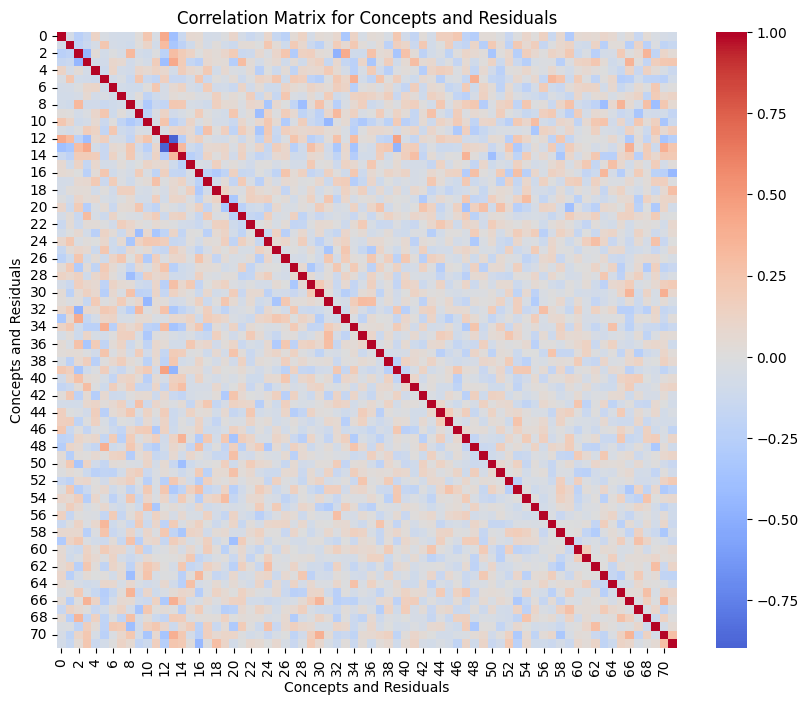

In [5]:
# Plot correlation matrix for concepts and residuals
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix
corr_matrix = torch.corrcoef(c_r_binarized.t())

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Concepts and Residuals')
plt.xlabel('Concepts and Residuals')
plt.ylabel('Concepts and Residuals')
plt.show()

In [ ]:
# Entropy calculation for each concept and residual
def calculate_entropy(probs):
    # Ensure probabilities are in the range (0, 1)
    probs = torch.clamp(probs, min=1e-10, max=1-1e-10)
    return -torch.sum(probs * torch.log(probs) + (1 - probs) * torch.log(1 - probs), dim=0)

# Print entropy for each concept and residual
entropy_values = calculate_entropy(c_r_probs)

# Make this into dataframe with columns: concept/residual, entropy, variation, active_count, inactive_count, ratio_active_inactive
data = []
variation_logits = torch.var(c_r_logits, dim=0)
active_counts = torch.sum(c_r_binarized, dim=0)
inactive_counts = c_r_binarized.shape[0] - active_counts
ratio_active_inactive = active_counts / (inactive_counts + active_counts + 1e-10)

# Also add most correlated residual for each concept and vice versa, and the correlation value
for i in range(c_r_binarized.shape[1]):
    if i < 22:
        data.append({
            "concept/residual": f"Concept {i}",
            "entropy": entropy_values[i].item(),
            "variance logits": variation_logits[i].item(),
            "active_count": active_counts[i].item(),
            "inactive_count": inactive_counts[i].item(),
            "ratio_active_inactive": ratio_active_inactive[i].item(),
            "most correlated residual": f"Residual {torch.argmax(corr_matrix[i, 22:]).item()}",
            "correlation value": corr_matrix[i, 22 + torch.argmax(corr_matrix[i, 22:])].item()
        })
    else:
        data.append({
            "concept/residual": f"Residual {i-22}",
            "entropy": entropy_values[i].item(),
            "variance logits": variation_logits[i].item(),
            "active_count": active_counts[i].item(),
            "inactive_count": inactive_counts[i].item(),
            "ratio_active_inactive": ratio_active_inactive[i].item(),
            "most correlated concept": f"Concept {torch.argmax(corr_matrix[i, :22]).item()}",
            "correlation value": corr_matrix[i, torch.argmax(corr_matrix[i, :22])].item()
        })
        
import pandas as pd
df = pd.DataFrame(data)
# dislay all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df)

,concept/residual,entropy,variation,active_count,inactive_count,ratio_active_inactive,most correlated residual,correlation value,most correlated concept
0,Concept 0,NaN,0.068799,374.0,4422.0,0.077982,Residual 24,0.227324,NaN
1,Concept 1,NaN,0.052004,276.0,4520.0,0.057548,Residual 2,0.215092,NaN
2,Concept 2,NaN,0.220429,1916.0,2880.0,0.399500,Residual 11,0.402419,NaN
3,Concept 3,NaN,0.170221,1145.0,3651.0,0.238741,Residual 44,0.358201,NaN
4,Concept 4,96.326111,0.043581,230.0,4566.0,0.047957,Residual 9,0.197369,NaN
5,Concept 5,NaN,0.154555,1009.0,3787.0,0.210384,Residual 12,0.377341,NaN
6,Concept 6,NaN,0.054862,293.0,4503.0,0.061093,Residual 47,0.208606,NaN
7,Concept 7,NaN,0.073210,408.0,4388.0,0.085071,Residual 4,0.230382,NaN
8,Concept 8,NaN,0.115090,664.0,4132.0,0.138449,Residual 43,0.353471,NaN
9,Concept 9,NaN,0.126187,757.0,4039.0,0.157840,Residual 10,0.323091,NaN


In [7]:
# Calculate the variation of probabilites for each concept and residual
variation_probs = torch.var(c_r_probs, dim=0)
# First 22 are concepts, rest are residuals
print("Variation of probabilities for each concept and residual:")
for i, var in enumerate(variation_probs):
    if i < 22:
        print(f"  Concept {i}: {var.item()}")
    else:
        print(f"  Residual {i-22}: {var.item()}") 

Variation of probabilities for each concept and residual:
  Concept 0: 0.0687989741563797
  Concept 1: 0.052004050463438034
  Concept 2: 0.22042901813983917
  Concept 3: 0.17022135853767395
  Concept 4: 0.04358118027448654
  Concept 5: 0.1545548290014267
  Concept 6: 0.0548623763024807
  Concept 7: 0.07320957630872726
  Concept 8: 0.11508981883525848
  Concept 9: 0.1261867880821228
  Concept 10: 0.21469539403915405
  Concept 11: 0.09394412487745285
  Concept 12: 0.20671357214450836
  Concept 13: 0.21614539623260498
  Concept 14: 0.22066602110862732
  Concept 15: 0.11374228447675705
  Concept 16: 0.2233201563358307
  Concept 17: 0.05254298076033592
  Concept 18: 0.09957119077444077
  Concept 19: 0.09507571905851364
  Concept 20: 0.22574862837791443
  Concept 21: 0.04372309148311615
  Residual 0: 0.19153690338134766
  Residual 1: 0.19942882657051086
  Residual 2: 0.19719141721725464
  Residual 3: 0.1970258504152298
  Residual 4: 0.20055115222930908
  Residual 5: 0.1911451816558838
  Resi

# Plot the distributions

In [ ]:
import matplotlib.pyplot as plt
import math

# Plot the logit distribution of every concept and residual in one figure, 3 per row,
# annotated with each dimension's activation rate (fraction of samples with prob > 0.5)
num_concepts = 22
num_dims = c_r_logits.shape[1]
num_cols = 3
num_rows = math.ceil(num_dims / num_cols)

activation_rates = c_r_binarized.mean(dim=0)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims):
    ax = axes[i]
    is_concept = i < num_concepts
    label = f"Concept {i}" if is_concept else f"Residual {i - num_concepts}"
    ax.hist(c_r_logits[:, i].numpy(), bins=50, color="tab:blue" if is_concept else "tab:orange")
    ax.set_title(label, fontsize=9)
    ax.text(
        0.98, 0.95,
        f"active: {activation_rates[i].item():.2%}",
        transform=ax.transAxes,
        ha="right", va="top", fontsize=8,
    )

# Hide any unused axes
for ax in axes[num_dims:]:
    ax.axis("off")

fig.suptitle("Distribution of logits per concept/residual (train split)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
import pickle
import torch
import os

dataset_root = os.path.join("datasets", "CUB", "class_attr_data_10")

for split in ["train", "val", "test"]:
    y_pred = torch.load(
        os.path.join(EXPERIMENT_PATH, split, "y_pred.pt")
    )

    split_path = os.path.join(dataset_root, f"{split}.pkl")
    with open(split_path, "rb") as f:
        split_data = pickle.load(f)

    y_true = torch.tensor(
        [example["class_label"] for example in split_data],
        dtype=torch.long,
    )

    print(split, y_pred.shape, y_true.shape)

train torch.Size([4796, 200]) torch.Size([4796])
val torch.Size([1198, 200]) torch.Size([1198])


/var/folders/wb/9whmmh7s5bvf174ppr2jwprr0000gn/T/ipykernel_47752/1013308238.py:14: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  split_data = pickle.load(f)


test torch.Size([5794, 200]) torch.Size([5794])


## Check that the CUB dataset is correct

In [9]:
ATTRIBUTES_IDX_USED = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, \
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, \
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, \
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]




def get_attribute_parts_to_indices():
    """
    Maps attribute idx to attribute parts (e.g. bill, wing, etc.)
    """
    
    
    # Attribute idx in the original 312 attribute space to attribute idx in the new 112 attribute space
    old_idx_to_new_idx = {old_idx: new_idx for new_idx, old_idx in enumerate(ATTRIBUTES_IDX_USED)}
    #print(old_idx_to_new_idx)
    

    path_attrubute_file = os.path.join("datasets", "CUB/CUB_200_2011/attributes.txt")



    with open(path_attrubute_file, "r") as f:
        lines = f.readlines()
        semantic_groups = {}
        for line in lines:
            idx, attr_name = line.strip().split(" ")
            idx = int(idx) - 1 # Convert to 0-based index
            if idx not in ATTRIBUTES_IDX_USED:
                continue
                
            new_idx = old_idx_to_new_idx[idx]
            semantic_group = attr_name.split("::")[0]
            if semantic_group not in semantic_groups:
                semantic_groups[semantic_group] = []
            semantic_groups[semantic_group].append(new_idx)

        return semantic_groups
    
    
print("Attribute parts to indices mapping:")
attribute_parts_to_indices = get_attribute_parts_to_indices()
for part, indices in attribute_parts_to_indices.items():
    print(f"{part}: {indices}")
    

Attribute parts to indices mapping:
has_bill_shape: [0, 1, 2, 3]
has_wing_color: [4, 5, 6, 7, 8, 9]
has_upperparts_color: [10, 11, 12, 13, 14, 15]
has_underparts_color: [16, 17, 18, 19, 20, 21]
has_breast_pattern: [22, 23, 24]
has_back_color: [25, 26, 27, 28, 29, 30]
has_tail_shape: [31]
has_upper_tail_color: [32, 33, 34, 35, 36]
has_head_pattern: [37, 38]
has_breast_color: [39, 40, 41, 42, 43, 44]
has_throat_color: [45, 46, 47, 48, 49]
has_eye_color: [50]
has_bill_length: [51, 52]
has_forehead_color: [53, 54, 55, 56, 57, 58]
has_under_tail_color: [59, 60, 61, 62, 63]
has_nape_color: [64, 65, 66, 67, 68, 69]
has_belly_color: [70, 71, 72, 73, 74, 75]
has_wing_shape: [76, 77]
has_size: [78, 79, 80]
has_shape: [81, 82]
has_back_pattern: [83, 84, 85]
has_tail_pattern: [86, 87, 88]
has_belly_pattern: [89]
has_primary_color: [90, 91, 92, 93, 94, 95]
has_leg_color: [96, 97, 98]
has_bill_color: [99, 100, 101]
has_crown_color: [102, 103, 104, 105, 106, 107]
has_wing_pattern: [108, 109, 110, 111

In [10]:
from collections import defaultdict


SELECTED_CONCEPTS = [
    1,
    4,
    6,
    7,
    10,
    14,
    15,
    20,
    21,
    23,
    25,
    29,
    30,
    35,
    36,
    38,
    40,
    44,
    45,
    50,
    51,
    53,
    54,
    56,
    57,
    59,
    63,
    64,
    69,
    70,
    72,
    75,
    80,
    84,
    90,
    91,
    93,
    99,
    101,
    106,
    110,
    111,
    116,
    117,
    119,
    125,
    126,
    131,
    132,
    134,
    145,
    149,
    151,
    152,
    153,
    157,
    158,
    163,
    164,
    168,
    172,
    178,
    179,
    181,
    183,
    187,
    188,
    193,
    194,
    196,
    198,
    202,
    203,
    208,
    209,
    211,
    212,
    213,
    218,
    220,
    221,
    225,
    235,
    236,
    238,
    239,
    240,
    242,
    243,
    244,
    249,
    253,
    254,
    259,
    260,
    262,
    268,
    274,
    277,
    283,
    289,
    292,
    293,
    294,
    298,
    299,
    304,
    305,
    308,
    309,
    310,
    311,
]

# Names of all CUB attributes
CONCEPT_SEMANTICS = [
    "has_bill_shape::curved_(up_or_down)",
    "has_bill_shape::dagger",
    "has_bill_shape::hooked",
    "has_bill_shape::needle",
    "has_bill_shape::hooked_seabird",
    "has_bill_shape::spatulate",
    "has_bill_shape::all-purpose",
    "has_bill_shape::cone",
    "has_bill_shape::specialized",
    "has_wing_color::blue",
    "has_wing_color::brown",
    "has_wing_color::iridescent",
    "has_wing_color::purple",
    "has_wing_color::rufous",
    "has_wing_color::grey",
    "has_wing_color::yellow",
    "has_wing_color::olive",
    "has_wing_color::green",
    "has_wing_color::pink",
    "has_wing_color::orange",
    "has_wing_color::black",
    "has_wing_color::white",
    "has_wing_color::red",
    "has_wing_color::buff",
    "has_upperparts_color::blue",
    "has_upperparts_color::brown",
    "has_upperparts_color::iridescent",
    "has_upperparts_color::purple",
    "has_upperparts_color::rufous",
    "has_upperparts_color::grey",
    "has_upperparts_color::yellow",
    "has_upperparts_color::olive",
    "has_upperparts_color::green",
    "has_upperparts_color::pink",
    "has_upperparts_color::orange",
    "has_upperparts_color::black",
    "has_upperparts_color::white",
    "has_upperparts_color::red",
    "has_upperparts_color::buff",
    "has_underparts_color::blue",
    "has_underparts_color::brown",
    "has_underparts_color::iridescent",
    "has_underparts_color::purple",
    "has_underparts_color::rufous",
    "has_underparts_color::grey",
    "has_underparts_color::yellow",
    "has_underparts_color::olive",
    "has_underparts_color::green",
    "has_underparts_color::pink",
    "has_underparts_color::orange",
    "has_underparts_color::black",
    "has_underparts_color::white",
    "has_underparts_color::red",
    "has_underparts_color::buff",
    "has_breast_pattern::solid",
    "has_breast_pattern::spotted",
    "has_breast_pattern::striped",
    "has_breast_pattern::multi-colored",
    "has_back_color::blue",
    "has_back_color::brown",
    "has_back_color::iridescent",
    "has_back_color::purple",
    "has_back_color::rufous",
    "has_back_color::grey",
    "has_back_color::yellow",
    "has_back_color::olive",
    "has_back_color::green",
    "has_back_color::pink",
    "has_back_color::orange",
    "has_back_color::black",
    "has_back_color::white",
    "has_back_color::red",
    "has_back_color::buff",
    "has_tail_shape::forked_tail",
    "has_tail_shape::rounded_tail",
    "has_tail_shape::notched_tail",
    "has_tail_shape::fan-shaped_tail",
    "has_tail_shape::pointed_tail",
    "has_tail_shape::squared_tail",
    "has_upper_tail_color::blue",
    "has_upper_tail_color::brown",
    "has_upper_tail_color::iridescent",
    "has_upper_tail_color::purple",
    "has_upper_tail_color::rufous",
    "has_upper_tail_color::grey",
    "has_upper_tail_color::yellow",
    "has_upper_tail_color::olive",
    "has_upper_tail_color::green",
    "has_upper_tail_color::pink",
    "has_upper_tail_color::orange",
    "has_upper_tail_color::black",
    "has_upper_tail_color::white",
    "has_upper_tail_color::red",
    "has_upper_tail_color::buff",
    "has_head_pattern::spotted",
    "has_head_pattern::malar",
    "has_head_pattern::crested",
    "has_head_pattern::masked",
    "has_head_pattern::unique_pattern",
    "has_head_pattern::eyebrow",
    "has_head_pattern::eyering",
    "has_head_pattern::plain",
    "has_head_pattern::eyeline",
    "has_head_pattern::striped",
    "has_head_pattern::capped",
    "has_breast_color::blue",
    "has_breast_color::brown",
    "has_breast_color::iridescent",
    "has_breast_color::purple",
    "has_breast_color::rufous",
    "has_breast_color::grey",
    "has_breast_color::yellow",
    "has_breast_color::olive",
    "has_breast_color::green",
    "has_breast_color::pink",
    "has_breast_color::orange",
    "has_breast_color::black",
    "has_breast_color::white",
    "has_breast_color::red",
    "has_breast_color::buff",
    "has_throat_color::blue",
    "has_throat_color::brown",
    "has_throat_color::iridescent",
    "has_throat_color::purple",
    "has_throat_color::rufous",
    "has_throat_color::grey",
    "has_throat_color::yellow",
    "has_throat_color::olive",
    "has_throat_color::green",
    "has_throat_color::pink",
    "has_throat_color::orange",
    "has_throat_color::black",
    "has_throat_color::white",
    "has_throat_color::red",
    "has_throat_color::buff",
    "has_eye_color::blue",
    "has_eye_color::brown",
    "has_eye_color::purple",
    "has_eye_color::rufous",
    "has_eye_color::grey",
    "has_eye_color::yellow",
    "has_eye_color::olive",
    "has_eye_color::green",
    "has_eye_color::pink",
    "has_eye_color::orange",
    "has_eye_color::black",
    "has_eye_color::white",
    "has_eye_color::red",
    "has_eye_color::buff",
    "has_bill_length::about_the_same_as_head",
    "has_bill_length::longer_than_head",
    "has_bill_length::shorter_than_head",
    "has_forehead_color::blue",
    "has_forehead_color::brown",
    "has_forehead_color::iridescent",
    "has_forehead_color::purple",
    "has_forehead_color::rufous",
    "has_forehead_color::grey",
    "has_forehead_color::yellow",
    "has_forehead_color::olive",
    "has_forehead_color::green",
    "has_forehead_color::pink",
    "has_forehead_color::orange",
    "has_forehead_color::black",
    "has_forehead_color::white",
    "has_forehead_color::red",
    "has_forehead_color::buff",
    "has_under_tail_color::blue",
    "has_under_tail_color::brown",
    "has_under_tail_color::iridescent",
    "has_under_tail_color::purple",
    "has_under_tail_color::rufous",
    "has_under_tail_color::grey",
    "has_under_tail_color::yellow",
    "has_under_tail_color::olive",
    "has_under_tail_color::green",
    "has_under_tail_color::pink",
    "has_under_tail_color::orange",
    "has_under_tail_color::black",
    "has_under_tail_color::white",
    "has_under_tail_color::red",
    "has_under_tail_color::buff",
    "has_nape_color::blue",
    "has_nape_color::brown",
    "has_nape_color::iridescent",
    "has_nape_color::purple",
    "has_nape_color::rufous",
    "has_nape_color::grey",
    "has_nape_color::yellow",
    "has_nape_color::olive",
    "has_nape_color::green",
    "has_nape_color::pink",
    "has_nape_color::orange",
    "has_nape_color::black",
    "has_nape_color::white",
    "has_nape_color::red",
    "has_nape_color::buff",
    "has_belly_color::blue",
    "has_belly_color::brown",
    "has_belly_color::iridescent",
    "has_belly_color::purple",
    "has_belly_color::rufous",
    "has_belly_color::grey",
    "has_belly_color::yellow",
    "has_belly_color::olive",
    "has_belly_color::green",
    "has_belly_color::pink",
    "has_belly_color::orange",
    "has_belly_color::black",
    "has_belly_color::white",
    "has_belly_color::red",
    "has_belly_color::buff",
    "has_wing_shape::rounded-wings",
    "has_wing_shape::pointed-wings",
    "has_wing_shape::broad-wings",
    "has_wing_shape::tapered-wings",
    "has_wing_shape::long-wings",
    "has_size::large_(16_-_32_in)",
    "has_size::small_(5_-_9_in)",
    "has_size::very_large_(32_-_72_in)",
    "has_size::medium_(9_-_16_in)",
    "has_size::very_small_(3_-_5_in)",
    "has_shape::upright-perching_water-like",
    "has_shape::chicken-like-marsh",
    "has_shape::long-legged-like",
    "has_shape::duck-like",
    "has_shape::owl-like",
    "has_shape::gull-like",
    "has_shape::hummingbird-like",
    "has_shape::pigeon-like",
    "has_shape::tree-clinging-like",
    "has_shape::hawk-like",
    "has_shape::sandpiper-like",
    "has_shape::upland-ground-like",
    "has_shape::swallow-like",
    "has_shape::perching-like",
    "has_back_pattern::solid",
    "has_back_pattern::spotted",
    "has_back_pattern::striped",
    "has_back_pattern::multi-colored",
    "has_tail_pattern::solid",
    "has_tail_pattern::spotted",
    "has_tail_pattern::striped",
    "has_tail_pattern::multi-colored",
    "has_belly_pattern::solid",
    "has_belly_pattern::spotted",
    "has_belly_pattern::striped",
    "has_belly_pattern::multi-colored",
    "has_primary_color::blue",
    "has_primary_color::brown",
    "has_primary_color::iridescent",
    "has_primary_color::purple",
    "has_primary_color::rufous",
    "has_primary_color::grey",
    "has_primary_color::yellow",
    "has_primary_color::olive",
    "has_primary_color::green",
    "has_primary_color::pink",
    "has_primary_color::orange",
    "has_primary_color::black",
    "has_primary_color::white",
    "has_primary_color::red",
    "has_primary_color::buff",
    "has_leg_color::blue",
    "has_leg_color::brown",
    "has_leg_color::iridescent",
    "has_leg_color::purple",
    "has_leg_color::rufous",
    "has_leg_color::grey",
    "has_leg_color::yellow",
    "has_leg_color::olive",
    "has_leg_color::green",
    "has_leg_color::pink",
    "has_leg_color::orange",
    "has_leg_color::black",
    "has_leg_color::white",
    "has_leg_color::red",
    "has_leg_color::buff",
    "has_bill_color::blue",
    "has_bill_color::brown",
    "has_bill_color::iridescent",
    "has_bill_color::purple",
    "has_bill_color::rufous",
    "has_bill_color::grey",
    "has_bill_color::yellow",
    "has_bill_color::olive",
    "has_bill_color::green",
    "has_bill_color::pink",
    "has_bill_color::orange",
    "has_bill_color::black",
    "has_bill_color::white",
    "has_bill_color::red",
    "has_bill_color::buff",
    "has_crown_color::blue",
    "has_crown_color::brown",
    "has_crown_color::iridescent",
    "has_crown_color::purple",
    "has_crown_color::rufous",
    "has_crown_color::grey",
    "has_crown_color::yellow",
    "has_crown_color::olive",
    "has_crown_color::green",
    "has_crown_color::pink",
    "has_crown_color::orange",
    "has_crown_color::black",
    "has_crown_color::white",
    "has_crown_color::red",
    "has_crown_color::buff",
    "has_wing_pattern::solid",
    "has_wing_pattern::spotted",
    "has_wing_pattern::striped",
    "has_wing_pattern::multi-colored",
]

# Generate a mapping containing all concept groups in CUB generated
# using a simple prefix tree
CONCEPT_GROUP_MAP = defaultdict(list)
for i, concept_name in enumerate(list(
    np.array(CONCEPT_SEMANTICS)[SELECTED_CONCEPTS]
)):
    group = concept_name[:concept_name.find("::")]
    CONCEPT_GROUP_MAP[group].append(i)

print("Concept groups and their indices:")
for group, indices in CONCEPT_GROUP_MAP.items():
    print(f"  {group}: {indices}")

Concept groups and their indices:
  has_bill_shape: [0, 1, 2, 3]
  has_wing_color: [4, 5, 6, 7, 8, 9]
  has_upperparts_color: [10, 11, 12, 13, 14, 15]
  has_underparts_color: [16, 17, 18, 19, 20, 21]
  has_breast_pattern: [22, 23, 24]
  has_back_color: [25, 26, 27, 28, 29, 30]
  has_tail_shape: [31]
  has_upper_tail_color: [32, 33, 34, 35, 36]
  has_head_pattern: [37, 38]
  has_breast_color: [39, 40, 41, 42, 43, 44]
  has_throat_color: [45, 46, 47, 48, 49]
  has_eye_color: [50]
  has_bill_length: [51, 52]
  has_forehead_color: [53, 54, 55, 56, 57, 58]
  has_under_tail_color: [59, 60, 61, 62, 63]
  has_nape_color: [64, 65, 66, 67, 68, 69]
  has_belly_color: [70, 71, 72, 73, 74, 75]
  has_wing_shape: [76, 77]
  has_size: [78, 79, 80]
  has_shape: [81, 82]
  has_back_pattern: [83, 84, 85]
  has_tail_pattern: [86, 87, 88]
  has_belly_pattern: [89]
  has_primary_color: [90, 91, 92, 93, 94, 95]
  has_leg_color: [96, 97, 98]
  has_bill_color: [99, 100, 101]
  has_crown_color: [102, 103, 104, 

In [11]:
# Check if the two dictionaries are consistent
for group, indices in CONCEPT_GROUP_MAP.items():
    indices_second = attribute_parts_to_indices.get(group, [])
    if set(indices) != set(indices_second):
        print(f"Mismatch in group '{group}':")
        print(f"  CONCEPT_GROUP_MAP indices: {indices}")
        print(f"  attribute_parts_to_indices indices: {indices_second}")

## Concept & residual activation by class

In [12]:
num_concepts = 22
num_residuals = c_r_probs.shape[1] - num_concepts
dim_names = list(range(c_r_probs.shape[1]))  # 0..21 concepts, 22..71 residuals
class_names = list(range(200))

print(f"{num_concepts} concepts, {num_residuals} residuals, {len(class_names)} classes")

22 concepts, 50 residuals, 200 classes


In [13]:
# Mean predicted activation probability of each concept/residual, per ground-truth class.
# Reload train y_true explicitly: an earlier cell (loop over train/val/test) overwrites
# the global y_true with the test split's version as a side effect.
y_true_train = torch.load(os.path.join(EXPERIMENT_PATH, "train", "y_true.pt"))

df_dims = pd.DataFrame(c_r_probs.numpy(), columns=dim_names)
df_dims["class"] = y_true_train.numpy()
class_means = df_dims.groupby("class").mean()
class_means.index = [class_names[i] for i in class_means.index]

print("class_means shape:", class_means.shape)
class_means.head()

class_means shape: (200, 72)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71
0,0.005857,0.958523,0.006632,0.015208,0.001089,0.054327,0.005823,0.005893,0.004041,0.058043,0.040238,0.004995,0.971041,0.020269,0.012503,0.003775,0.980736,0.001179,0.009022,0.002647,0.035680,0.005454,0.993122,0.070861,0.965646,0.056925,0.980706,0.975407,0.901791,0.828463,0.039490,0.972378,0.979017,0.094408,0.962585,0.978063,0.931980,0.070866,0.052771,0.906530,0.940339,0.045835,0.990094,0.841518,0.975511,0.992153,0.768429,0.034245,0.327070,0.018941,0.990940,0.994461,0.045631,0.981252,0.078580,0.960770,0.842863,0.114037,0.187514,0.974269,0.222383,0.050007,0.943897,0.040369,0.902921,0.810382,0.069797,0.986289,0.486796,0.964159,0.042160,0.036502
1,0.000361,0.997904,0.000329,0.000523,0.000035,0.005768,0.002595,0.000348,0.000124,0.000821,0.990189,0.003868,0.999091,0.000118,0.001792,0.000605,0.038301,0.000986,0.005094,0.000698,0.000539,0.977407,0.489964,0.068530,0.998537,0.069622,0.031492,0.995013,0.159509,0.892080,0.006399,0.946278,0.986903,0.983954,0.967453,0.938860,0.944192,0.082157,0.822742,0.991947,0.354680,0.994469,0.999103,0.602049,0.932693,0.972766,0.029364,0.953243,0.101869,0.002439,0.999539,0.992767,0.011030,0.929236,0.997729,0.982462,0.079213,0.000720,0.995890,0.997541,0.897397,0.052414,0.779071,0.001575,0.005974,0.999119,0.010193,0.980230,0.046174,0.991411,0.019321,0.053117
2,0.012571,0.887787,0.022556,0.024008,0.002068,0.018212,0.005626,0.005017,0.012030,0.016995,0.064731,0.003213,0.933057,0.038822,0.023800,0.007008,0.970192,0.000579,0.003745,0.001678,0.938463,0.002140,0.946394,0.095995,0.807050,0.125743,0.893676,0.974409,0.919940,0.634632,0.956216,0.927431,0.657820,0.087889,0.971512,0.928195,0.918508,0.110482,0.089944,0.830126,0.901153,0.135864,0.994460,0.237082,0.812210,0.992489,0.881310,0.009687,0.903732,0.023747,0.981543,0.993400,0.052898,0.968689,0.046098,0.881661,0.848323,0.083055,0.084196,0.893129,0.033909,0.057843,0.249076,0.085791,0.892835,0.923269,0.917730,0.967485,0.187446,0.924542,0.834077,0.055082
3,0.011694,0.003292,0.042476,0.085328,0.003022,0.915373,0.011653,0.006341,0.018908,0.918959,0.018022,0.006900,0.039351,0.964005,0.069170,0.011437,0.932472,0.005211,0.013091,0.012877,0.914968,0.004746,0.041333,0.173847,0.112750,0.940881,0.872823,0.570200,0.774364,0.888617,0.039402,0.786311,0.975385,0.924216,0.960584,0.127668,0.064769,0.974382,0.967072,0.194180,0.856610,0.159844,0.578372,0.942394,0.670288,0.126850,0.915999,0.139795,0.964891,0.933685,0.199301,0.942775,0.982053,0.782923,0.044506,0.872650,0.179681,0.973265,0.898023,0.067041,0.974343,0.112868,0.051312,0.551371,0.851658,0.025791,0.238127,0.265043,0.054977,0.059013,0.831733,0.882085
4,0.000390,0.007145,0.000720,0.002662,0.000483,0.002659,0.000121,0.973657,0.000889,0.986734,0.019587,0.000091,0.011296,0.985404,0.002095,0.971338,0.995879,0.000041,0.001335,0.000104,0.001934,0.000097,0.996782,0.031701,0.027752,0.000295,0.999823,0.817536,0.000356,0.970290,0.020360,0.984637,0.491863,0.013781,0.999497,0.892710,0.994393,0.972447,0.807633,0.176451,0.728341,0.012931,0.097309,0.388606,0.999765,0.830260,0.928991,0.050539,0.817325,0.066470,0.950736,0.993674,0.020705,0.999401,0.488394,0.980200,0.074624,0.987653,0.205720,0.964876,0.998382,0.892243,0.918824,0.951279,0.994357,0.017156,0.844614,0.936508,0.558527,0.997236,0.012813,0.003223


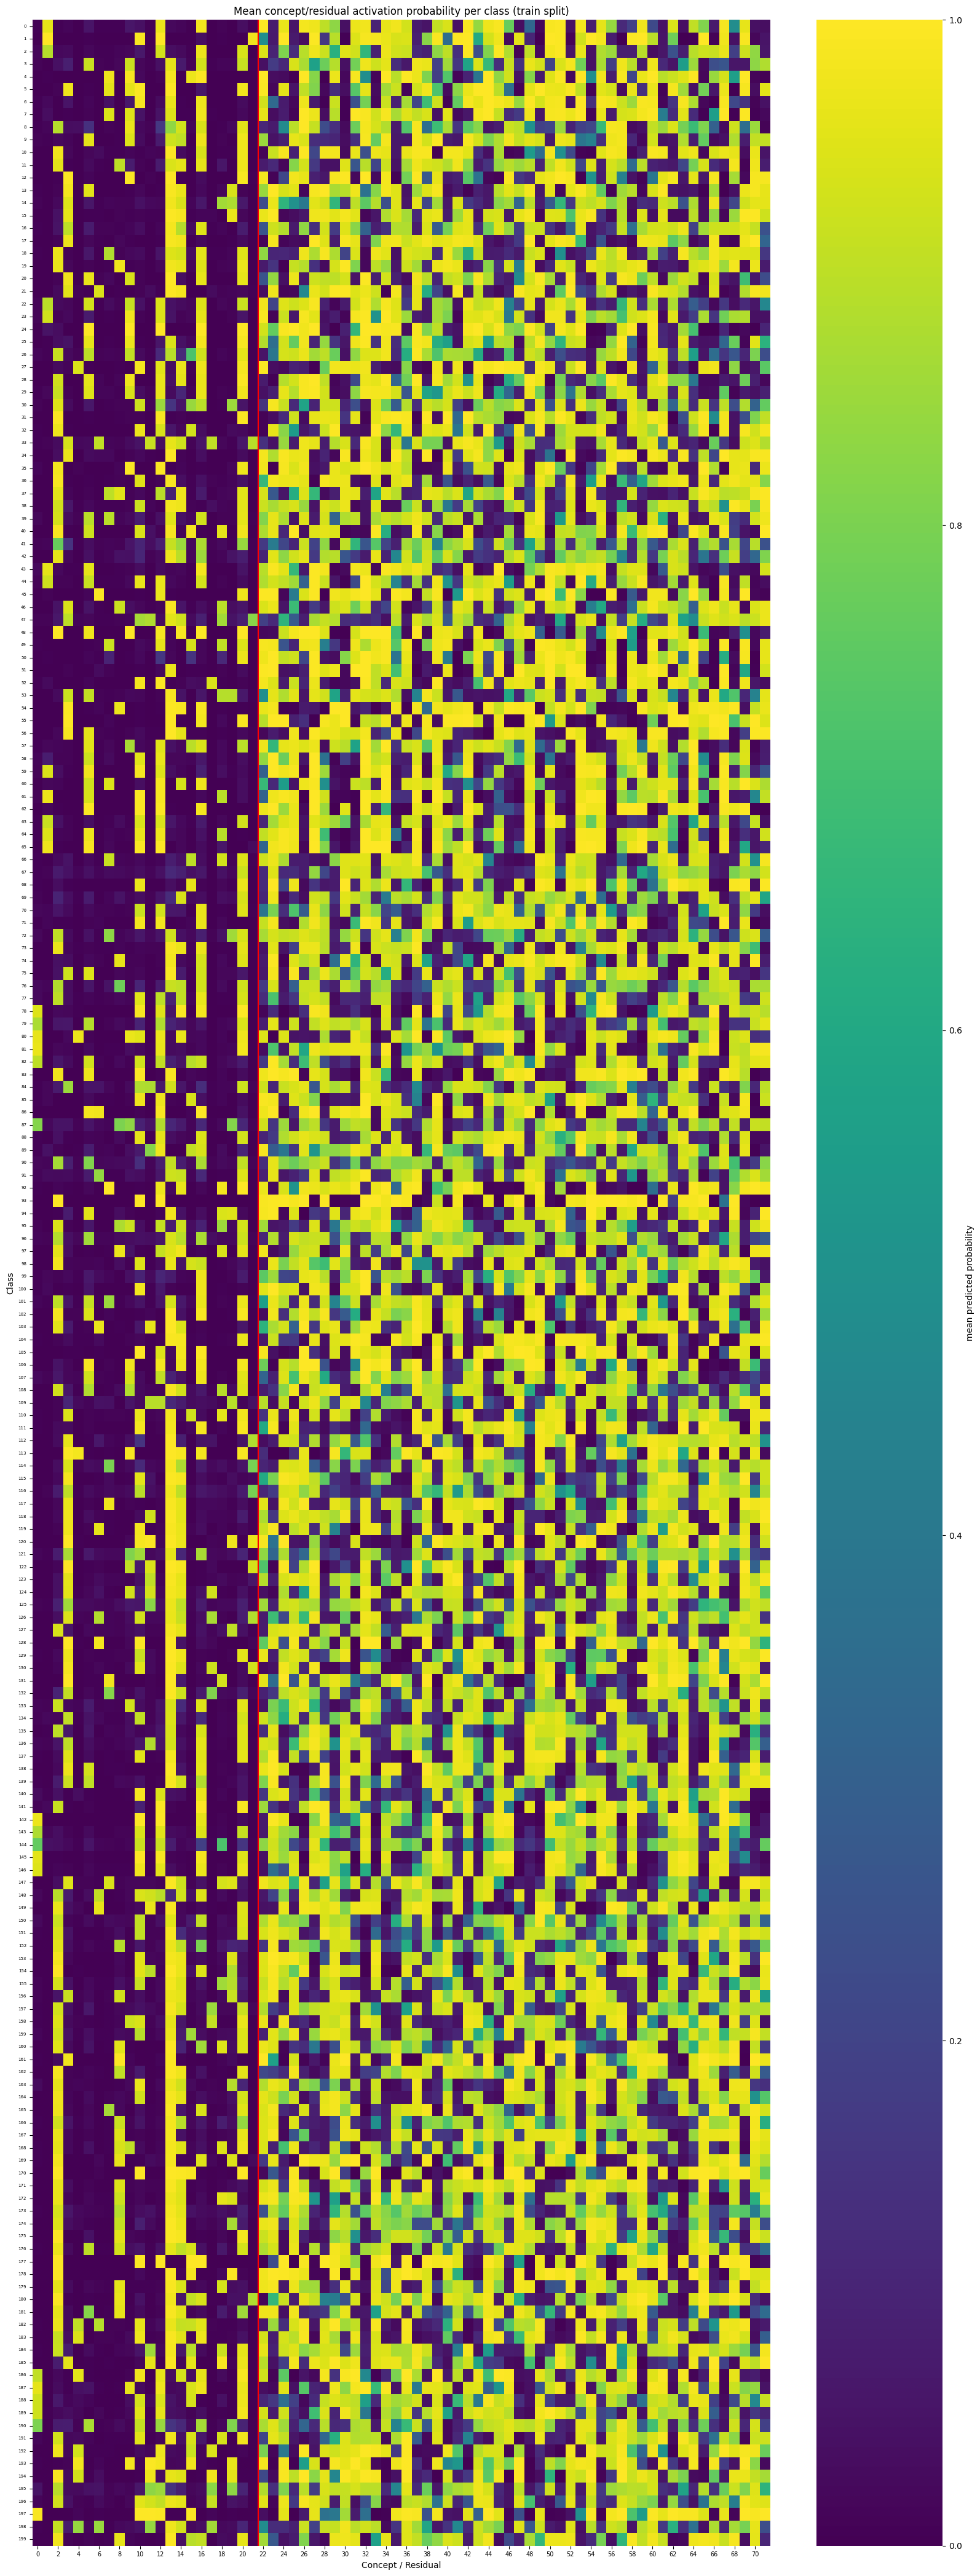

In [14]:
# Full heatmap: all 200 classes x all 22 concepts + 50 residuals
plt.figure(figsize=(16, 42))
sns.heatmap(
    class_means,
    cmap="viridis",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "mean predicted probability"},
)
plt.axvline(num_concepts, color="red", linewidth=1.5)  # concepts | residuals boundary
plt.title("Mean concept/residual activation probability per class (train split)")
plt.xlabel("Concept / Residual")
plt.ylabel("Class")
plt.xticks(fontsize=7)
plt.yticks(fontsize=5)
plt.tight_layout()
plt.show()

In [15]:
# Top-k most active concepts/residuals per class (quick lookup instead of scanning the full heatmap)
def top_active_dims(class_means, k=5):
    rows = []
    for cls_name, row in class_means.iterrows():
        top = row.sort_values(ascending=False).head(k)
        rows.append({
            "class": cls_name,
            **{f"top_{i+1}": f"{name} ({val:.2f})" for i, (name, val) in enumerate(top.items())},
        })
    return pd.DataFrame(rows).set_index("class")

top_dims_df = top_active_dims(class_means, k=5)
pd.set_option("display.max_rows", None)
display(top_dims_df)

,top_1,top_2,top_3,top_4,top_5
class,,,,,
0,51 (0.99),22 (0.99),45 (0.99),50 (0.99),42 (0.99)
1,50 (1.00),65 (1.00),42 (1.00),12 (1.00),24 (1.00)
2,42 (0.99),51 (0.99),45 (0.99),50 (0.98),27 (0.97)
3,52 (0.98),32 (0.98),37 (0.97),60 (0.97),57 (0.97)
4,26 (1.00),44 (1.00),34 (1.00),53 (1.00),60 (1.00)
5,43 (1.00),44 (1.00),49 (1.00),13 (1.00),22 (0.99)
6,53 (1.00),44 (1.00),48 (1.00),55 (0.99),59 (0.99)
7,53 (1.00),67 (1.00),44 (1.00),26 (1.00),31 (1.00)
8,26 (1.00),56 (0.99),37 (0.98),32 (0.98),57 (0.98)


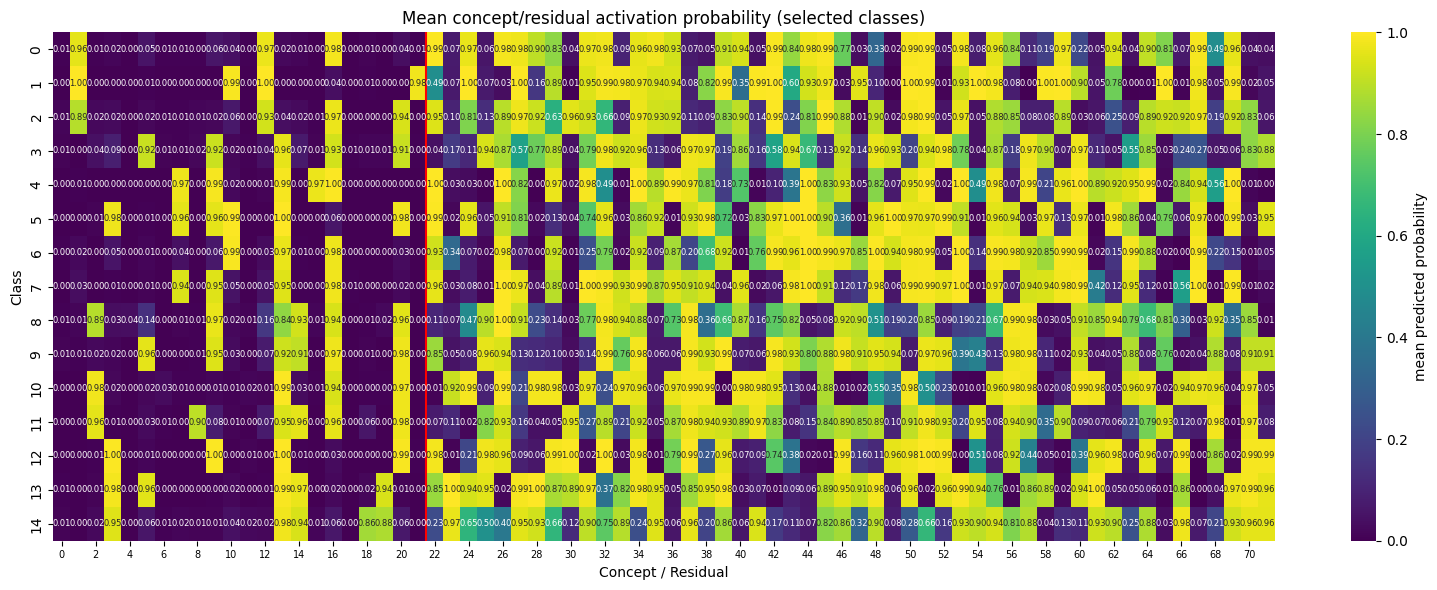

In [16]:
# Zoomed-in heatmap for a chosen subset of classes (edit CLASSES_TO_SHOW)
CLASSES_TO_SHOW = class_names[:15]  # e.g. class_names[:15], or pick specific species by name

plt.figure(figsize=(16, max(4, 0.4 * len(CLASSES_TO_SHOW))))
sns.heatmap(
    class_means.loc[CLASSES_TO_SHOW],
    cmap="viridis",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 6},
    cbar_kws={"label": "mean predicted probability"},
)
plt.axvline(num_concepts, color="red", linewidth=1.5)
plt.title("Mean concept/residual activation probability (selected classes)")
plt.xlabel("Concept / Residual")
plt.ylabel("Class")
plt.xticks(fontsize=7)
plt.tight_layout()
plt.show()